# Bootcamp 11: Practice with `solve_ivp`

I, Rainy Jain, commit to academic honesty and integrity. I am grateful for the education and knowledge i am able to receive, i respect every bit of this opportunity that's making me grow. Integrity is most important to me as i want to achieve something great in my life and it starts with every small step that i take with honesty to grow myself into a better version. The trust and expectations of my loved ones on me and the dreams that i want to come true keeps me going and motivates me to work in the best possible way. I commit that i will conduct myself with integrity and acknowledge towards my awareness about the ethical strandards for integrity of MSU

## 1. Modeling the Motion of a Spring

Let’s look at the motion of a spring. Spring motion follows one basic rule: *springs want to be a certain length. Stretching or compressing the spring away from its happy length makes the spring mad, and it will resist the change.* Mathematically, we can state this as:

$$\frac{dv}{dt} = -\frac{k}{m} (l - l_{\mathrm{unst}}) $$

Where
- $k$ is the spring constant. It determines how *stiff* the spring is. A larger $k$ means the spring will push (or pull) against you more.
- $m$ is the mass of the spring
- $l$ is the length of the spring
- $l_{\mathrm{unst}}$ is the unstretched length of the spring (it’s happy length)!

**NOTE** Remember from our work on Day 14 that this isn’t the only ODE we need to include in our model. We also need to include the equation for the change in *length*, that is:

$$\frac{dl}{dt} = v$$

Okay! Let’s model this motion!

&#9989;&nbsp; **Write a piece of code that models the motion of the spring.  You will need to set your initial variables, write a derivs function, and use it in a call to `solve_ivp`.** 

For values to plug into your equations (I.e., $k$, $m$, $l_{\mathrm{unst}}$, $v_0$ (initial velocity), $l_0$ (initial length)), pick your own! Anything between 0.5-2.0 should work just fine for any of the variables. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import solve_ivp

In [59]:
# Write your code here
def deriv(time,curr_vals):
    k=0.5
    m=2
    lu=3
    v,l = curr_vals
    dvdt = -k/m*(l-lu)
    dldt = v
    return dvdt,dldt
    

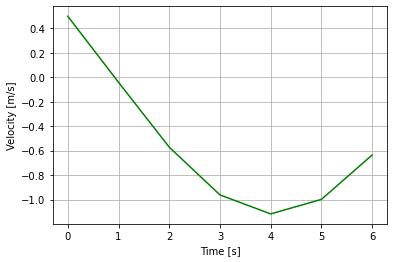

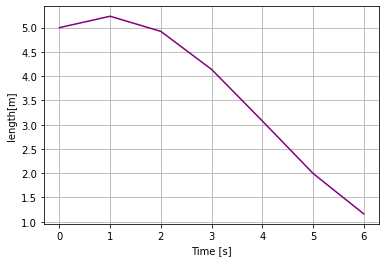

In [60]:
v0 = 0.5
l0 = 5

init=[v0,l0]
tmax= 6
dt =1
time = np.arange(0, tmax + dt, dt)
sol = solve_ivp(deriv,(0,tmax),init,t_eval = time)


plt.figure(1)
plt.plot(time, sol.y[0,:],color="green")
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.grid()

# Plot the velocity using the \"1\" element from the solution
plt.figure(2)
plt.plot(time, sol.y[1,:],color="purple")
plt.xlabel('Time [s]')
plt.ylabel('length[m]')
plt.grid()

&#9989;&nbsp; **QUESTION** Try out several different values for the spring constant $l_{\mathrm{unst}}$. How does $l$ change when you vary $l_{\mathrm{unst}}$? How does the velocity of the spring change? (**Note** It may be helpful to overplot the motion (i.e., $l$) for different $l_{\mathrm{unst}}$ values on a single plot, so you can easily compare them).

In [ ]:
# Write your code here

*Write your observations here for how $l$ and $v$ change when you vary $l_{\mathrm{unst}}$*

## 2. Adding in Damping

Now that we have a fun little model for our spring let’s make it a little bit more complex. Real springs don’t bounce back and forth indefinitely; instead, they will slowly die away. So! Let’s add a **damping term** that will cause the spring to not go on forever. 

To do this, we need to add another term to our equation for $\frac{dv}{dt}$. Specifically, 

$$\frac{dv}{dt} = -\frac{k}{m} (l - l_{\mathrm{unst}}) - c*v$$

Where $c$ is a damping coefficient, and $v$ is the velocity.

&#9989;&nbsp; **Using your code from the previous problem as a template, model the motion of a *damped* spring.**

Again, use your own value for $c$. Anything between 0.25 and 1.5 should be fine.

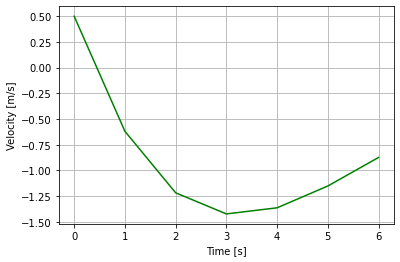

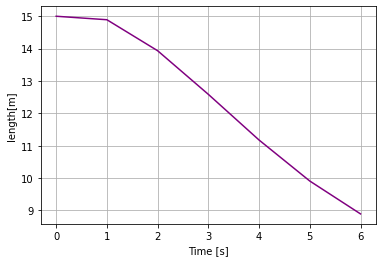

In [65]:
# Write your code here
# Write your code here
def deriv1(time,curr_vals,k,m,lu,c):
    v,l = curr_vals
    dvdt = -k/m*(l-lu) - c*v
    dldt = v
    return dvdt,dldt
k=0.5
m=3
lu=8
c=0.5
v0 = 0.5
l0 = 15

init=[v0,l0]
tmax= 6
dt =1
time = np.arange(0, tmax + dt, dt)
sol = solve_ivp(deriv1,(0,tmax),init,t_eval = time, args=(k,m,lu,c))


plt.figure(1)
plt.plot(time, sol.y[0,:],color="green")
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.grid()

# Plot the velocity using the \"1\" element from the solution
plt.figure(2)
plt.plot(time, sol.y[1,:],color="purple")
plt.xlabel('Time [s]')
plt.ylabel('length[m]')
plt.grid()

**QUESTION** Try out several different values for the spring constant $c$. How does $l$ change when you vary $c$? How does the velocity of the spring change? (**Note** It may be useful to overplot the motion (i.e., $l$) for different $c$ values on a single plot, so you can easily compare them).

In [ ]:
# Write your code here

*Write your observations here for how $l$ and $v$ change when you vary $c$*